**CNN for Classification of handwritten digit**

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow import keras
import numpy as np

**Loading dataset**

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

**Scaling the train and test dataset**

In [3]:
X_train = X_train / 255
X_test = X_test / 255

In [4]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [5]:
X_train.shape

(60000, 28, 28)

In [6]:
X_train = X_train.reshape(-1,28,28,1)
X_train.shape

(60000, 28, 28, 1)

In [7]:
X_test = X_test.reshape(-1,28,28,1)
X_test.shape

(10000, 28, 28, 1)

**Creating and Training a CNN**

In [8]:
convolutional_neural_network = models.Sequential([
    layers.Conv2D(filters=25, kernel_size=(3, 3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

C:\Users\oyelola Ibrahim\Desktop\my deep learning project\ANN_with_MNISTDATA\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
convolutional_neural_network.compile(optimizer='adam', loss='sparse_categorical_crossentropy',  metrics = ['accuracy'])
convolutional_neural_network.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - accuracy: 0.9316 - loss: 0.2230
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9763 - loss: 0.0773
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9832 - loss: 0.0548
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9864 - loss: 0.0453
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9888 - loss: 0.0358
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9904 - loss: 0.0292
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9929 - loss: 0.0233
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9938 - loss: 0.0198
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9944 - loss: 0.0170
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 20ms/step - accuracy: 0.9946 - loss: 0.0161


**Evaluating the CNN Model**

In [10]:
convolutional_neural_network.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9852 - loss: 0.0584


[0.05842818692326546, 0.9851999878883362]

**Making Predictions**

In [11]:
y_predicted_by_model = convolutional_neural_network.predict(X_test)
y_predicted_by_model[0]  #getting probability score for each class digits

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


array([4.6378452e-12, 1.1094239e-09, 6.8109593e-08, 7.2699645e-11,
       6.2902894e-10, 3.7566222e-12, 8.4275245e-17, 9.9999988e-01,
       9.0068916e-12, 1.8113691e-09], dtype=float32)

In [12]:
np.argmax(y_predicted_by_model[0])

np.int64(7)

In [13]:
y_predicted_labels = [np.argmax(i) for i in y_predicted_by_model]

In [14]:
y_predicted_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [16]:
#%pip install opencv-python

In [17]:
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

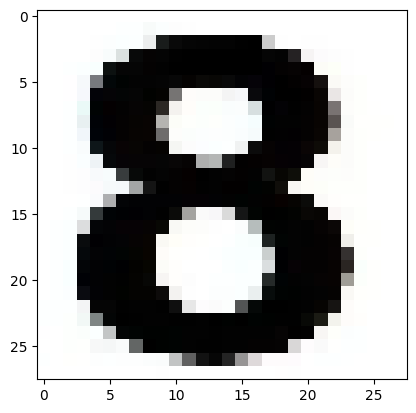

In [18]:
y = cv2.imread(r"C:\Users\oyelola Ibrahim\Desktop\8.webp")
y1 = cv2.resize(y,(28,28))
plt.imshow(y1)

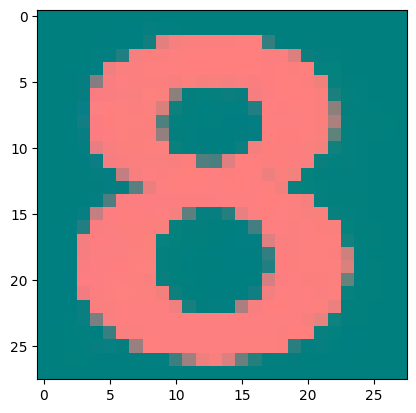

In [19]:
temp =cv2.cvtColor(y1,cv2.COLOR_BGR2YCrCb)
temp = 255-temp
plt.imshow(temp)  

In [20]:
print(temp.shape)

(28, 28, 3)


In [24]:
Y = np.zeros((temp.shape[0], temp.shape[1],1), dtype=float) #array of (28,28,1)
Y[:,:,0] = temp[:, :, 0].astype(float) /255  #fitting the data of temp image in that data and normalizing it
yh = convolutional_neural_network.predict(Y.reshape(1,28,28,1)) #finally the value of  image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


In [25]:
yh

array([[2.2732653e-10, 9.1122968e-16, 4.3499700e-08, 1.0471540e-11,
        4.5336946e-12, 2.2202663e-10, 1.7835960e-17, 2.3353725e-15,
        1.0000000e+00, 3.1394880e-12]], dtype=float32)

In [26]:
y_predicted_labels = [np.argmax(i) for i in yh]
y_predicted_labels

[np.int64(8)]